<a href="https://colab.research.google.com/github/Soflem0715/U3475_Lemecheva_Sophia_Andreevna/blob/%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%BE/%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%BE_%D0%9B%D0%B5%D0%BC%D0%B5%D1%88%D0%B5%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Визуализация Дерева**

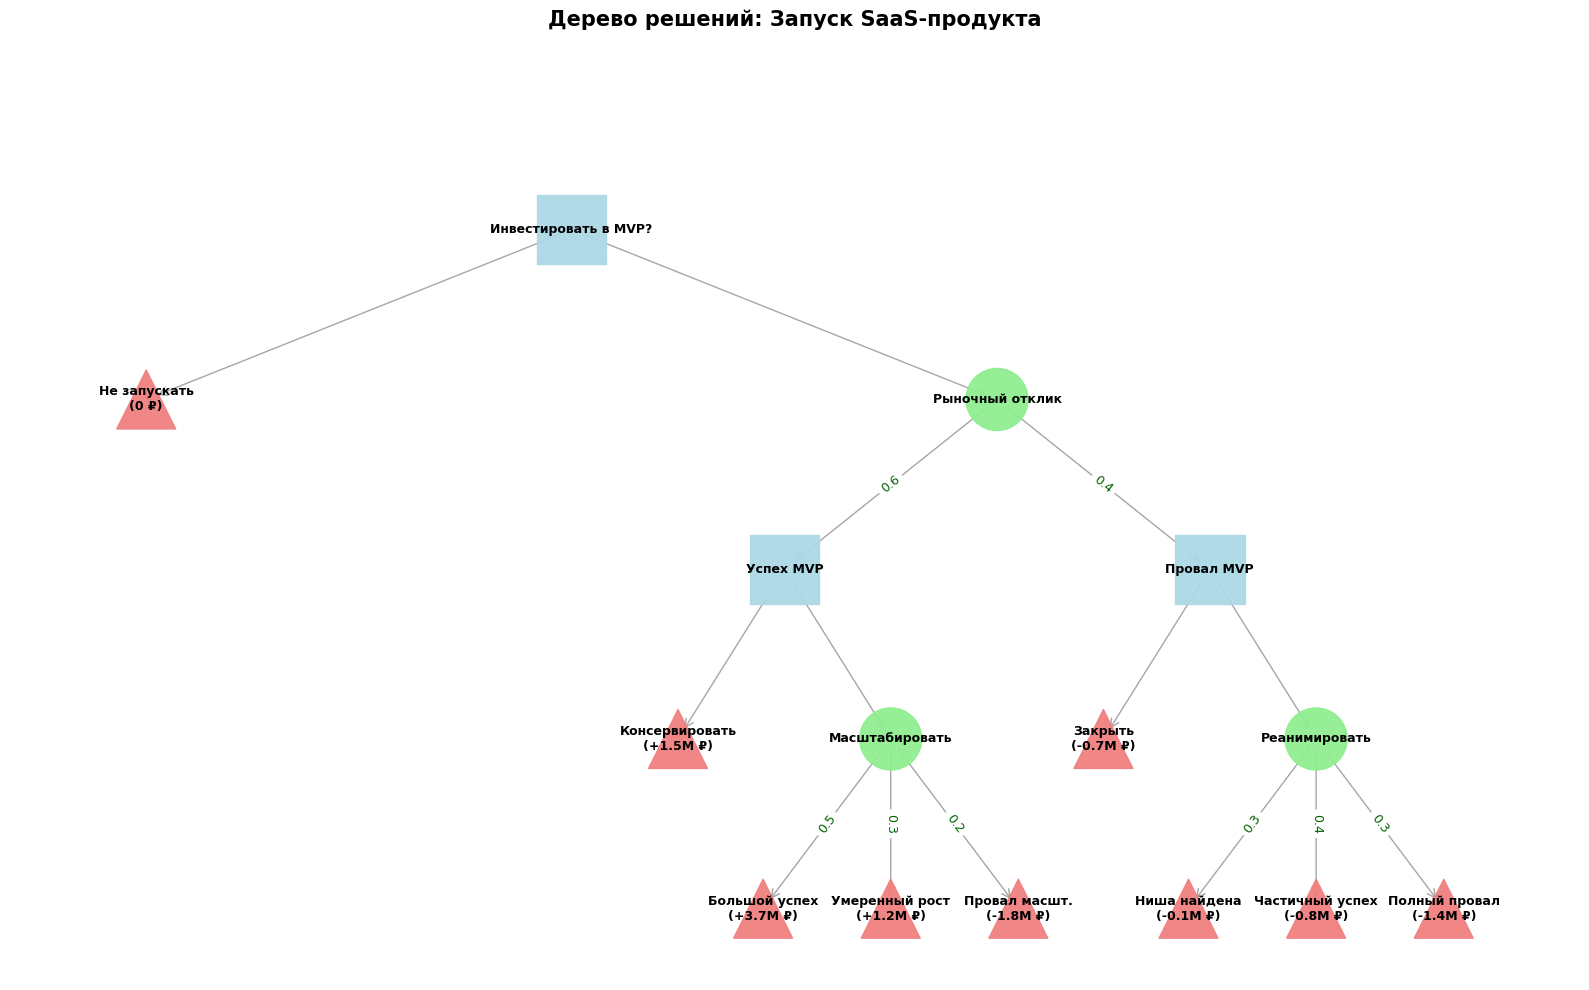

✅


In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1. ОПРЕДЕЛЕНИЕ СТРУКТУРЫ ДЕРЕВА
# ==============================

# Используем вложенные словари для описания дерева
def create_tree():
    tree = {
        'id': 'D1',
        'label': 'Инвестировать в MVP?',
        'type': 'decision',
        'children': [
            {
                'id': 'NoLaunch',
                'label': 'Не запускать\n(0 ₽)',
                'type': 'leaf',
                'value': 0
            },
            {
                'id': 'C1',
                'label': 'Рыночный отклик',
                'type': 'chance',
                'probs': [0.6, 0.4],
                'children': [
                    {
                        'id': 'D2',
                        'label': 'Успех MVP',
                        'type': 'decision',
                        'children': [
                            {
                                'id': 'Hold',
                                'label': 'Консервировать\n(+1.5M ₽)',
                                'type': 'leaf',
                                'value': 1_500_000
                            },
                            {
                                'id': 'C2',
                                'label': 'Масштабировать',
                                'type': 'chance',
                                'probs': [0.5, 0.3, 0.2],
                                'children': [
                                    {'id': 'BigSuccess', 'label': 'Большой успех\n(+3.7M ₽)', 'type': 'leaf', 'value': 3_700_000},
                                    {'id': 'ModestGrowth', 'label': 'Умеренный рост\n(+1.2M ₽)', 'type': 'leaf', 'value': 1_200_000},
                                    {'id': 'ScaleFail', 'label': 'Провал масшт.\n(-1.8M ₽)', 'type': 'leaf', 'value': -1_800_000}
                                ]
                            }
                        ]
                    },
                    {
                        'id': 'D3',
                        'label': 'Провал MVP',
                        'type': 'decision',
                        'children': [
                            {
                                'id': 'Close',
                                'label': 'Закрыть\n(-0.7M ₽)',
                                'type': 'leaf',
                                'value': -700_000
                            },
                            {
                                'id': 'C3',
                                'label': 'Реанимировать',
                                'type': 'chance',
                                'probs': [0.3, 0.4, 0.3],
                                'children': [
                                    {'id': 'PivotSuccess', 'label': 'Ниша найдена\n(-0.1M ₽)', 'type': 'leaf', 'value': -100_000},
                                    {'id': 'PartialPivot', 'label': 'Частичный успех\n(-0.8M ₽)', 'type': 'leaf', 'value': -800_000},
                                    {'id': 'PivotFail', 'label': 'Полный провал\n(-1.4M ₽)', 'type': 'leaf', 'value': -1_400_000}
                                ]
                            }
                        ]
                    }
                ]
            }
        ]
    }
    return tree

# ==================================
# 2. РЕКУРСИВНОЕ ПОСТРОЕНИЕ ГРАФА
# ==================================

def build_graph(node, parent_id=None, G=None, pos=None, x=0, y=0, depth=0, positions=None):
    if G is None:
        G = nx.DiGraph()
        pos = {}
        positions = {}
    node_id = node['id']
    G.add_node(node_id, **node)
    pos[node_id] = (x, -y)
    if parent_id is not None:
        G.add_edge(parent_id, node_id)
    if 'children' in node:
        n = len(node['children'])
        # Расстояние между детьми сужается с глубиной
        spacing = max(10 / (2 ** (depth)), 1.5)
        start_x = x - (n - 1) * spacing / 2
        for i, child in enumerate(node['children']):
            child_x = start_x + i * spacing
            build_graph(child, node_id, G, pos, child_x, y + 2.5, depth + 1, positions)
    return G, pos

# ==================================
# 3. ВИЗУАЛИЗАЦИЯ
# ==================================

def visualize_tree(G, pos):
    plt.figure(figsize=(16, 10))

    # Сбор цветов и форм
    node_colors = []
    node_shapes = []
    labels = {}

    for node_id in G.nodes():
        data = G.nodes[node_id]
        labels[node_id] = data['label']
        if data['type'] == 'decision':
            node_colors.append('lightblue')
            node_shapes.append('s')  # square
        elif data['type'] == 'chance':
            node_colors.append('lightgreen')
            node_shapes.append('o')  # circle
        else:  # leaf
            node_colors.append('lightcoral')
            node_shapes.append('^')  # triangle up

    # Рисуем узлы по типу
    for shape in set(node_shapes):
        nodes_with_shape = [n for n, s in zip(G.nodes(), node_shapes) if s == shape]
        colors_for_shape = [node_colors[i] for i, n in enumerate(G.nodes()) if node_shapes[i] == shape]
        nx.draw_networkx_nodes(
            G, pos, nodelist=nodes_with_shape,
            node_color=colors_for_shape,
            node_shape=shape,
            node_size=2500 if shape == 's' else (2000 if shape == 'o' else 1800),
            alpha=0.95
        )

    # Рёбра
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray', alpha=0.7)

    # Метки узлов
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

    # Подписи вероятностей на рёбрах от случайных узлов
    edge_labels = {}
    for u, v in G.edges():
        parent = G.nodes[u]
        if parent['type'] == 'chance':
            child_ids = [ch['id'] for ch in parent['children']]
            idx = child_ids.index(v)
            prob = parent['probs'][idx]
            edge_labels[(u, v)] = f"{prob:.1f}"

    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, font_color='darkgreen')

    plt.title("Дерево решений: Запуск SaaS-продукта", fontsize=15, weight='bold', pad=95)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("decision_tree_saas.png", dpi=200, bbox_inches='tight')
    plt.show()

# ==============================
# 4. ЗАПУСК
# ==============================

if __name__ == "__main__":
    tree = create_tree()
    G, pos = build_graph(tree)
    visualize_tree(G, pos)
    print("✅")



Анализ Дерева с помощью критериев принятия решения: Критерий Байеса, Критерий Лапласа, Критерий Вальда, Критерия Севиджа, Критерий Гурвица

In [32]:
import numpy as np
import pandas as pd

# Исходы для стратегии "Запустить MVP"
outcomes_launch = np.array([
    1_500_000,   # успех → hold
    3_700_000,   # успех → scale → большой
    1_200_000,   # успех → scale → умеренный
    -1_800_000,  # успех → scale → провал
    -700_000,    # провал → закрыть
    -100_000,    # провал → pivot → успех
    -800_000,    # провал → pivot → частичный
    -1_400_000   # провал → pivot → провал
])

probs_launch = np.array([
    0.6,
    0.6 * 0.5,
    0.6 * 0.3,
    0.6 * 0.2,
    0.4,
    0.4 * 0.3,
    0.4 * 0.4,
    0.4 * 0.3
])

# Стратегии
strategies = {
    'Не запускать': np.array([0]),
    'Запустить MVP': outcomes_launch
}

# -------------------------------
# Функции критериев
# -------------------------------

def bayes_criterion(outcomes, probs=None):
    """Критерий Байеса (математическое ожидание)"""
    if probs is None:
        raise ValueError("Для критерия Байеса нужны вероятности")
    return np.dot(outcomes, probs)

def laplace_criterion(outcomes):
    """Критерий Лапласа (равновероятное среднее)"""
    return np.mean(outcomes)

def wald_criterion(outcomes):
    """Критерий Вальда (максимин — самый худший исход)"""
    return np.min(outcomes)

def hurwicz_criterion(outcomes, alpha=0.5):
    """Критерий Гурвица: α * макс + (1-α) * мин"""
    return alpha * np.max(outcomes) + (1 - alpha) * np.min(outcomes)

def savage_criterion(strategies_dict):
    """Критерий Сэвиджа (минимакс сожалений)"""
    # Собираем все исходы
    all_outcomes = []
    for outs in strategies_dict.values():
        all_outcomes.extend(outs)
    global_max = np.max(all_outcomes)

    regrets = {}
    for name, outs in strategies_dict.items():
        worst_outcome = np.min(outs)
        max_regret = global_max - worst_outcome
        regrets[name] = max_regret
    return regrets

# -------------------------------
# Расчёт
# -------------------------------

results = {}

# Для "Не запускать"
results['Не запускать'] = {
    'Байес': 0,  # нет неопределённости
    'Лаплас': laplace_criterion(strategies['Не запускать']),
    'Вальд': wald_criterion(strategies['Не запускать']),
    'Гурвиц (α=0.5)': hurwicz_criterion(strategies['Не запускать'], 0.5)
}

# Для "Запустить MVP"
results['Запустить MVP'] = {
    'Байес': bayes_criterion(outcomes_launch, probs_launch),
    'Лаплас': laplace_criterion(outcomes_launch),
    'Вальд': wald_criterion(outcomes_launch),
    'Гурвиц (α=0.5)': hurwicz_criterion(outcomes_launch, 0.5)
}

# Критерий Сэвиджа (требует сравнения стратегий)
savage_vals = savage_criterion(strategies)
for name in results:
    results[name]['Сэвидж (макс. сожаление)'] = savage_vals[name]

# -------------------------------
# Вывод таблицы
# -------------------------------

df = pd.DataFrame(results).T
df = df.round(0).astype(int)
df.index.name = "Стратегия"

print("\n📊 Сравнение стратегий по критериям принятия решений:\n")
print(df.to_string(formatters={col: lambda x: f"{x:,.0f} ₽" for col in df.columns}))


📊 Сравнение стратегий по критериям принятия решений:

                    Байес    Лаплас        Вальд Гурвиц (α=0.5) Сэвидж (макс. сожаление)
Стратегия                                                                               
Не запускать          0 ₽       0 ₽          0 ₽            0 ₽              3,700,000 ₽
Запустить MVP 1,422,000 ₽ 200,000 ₽ -1,800,000 ₽      950,000 ₽              5,500,000 ₽
